In [2]:
import h5py
import numpy as np

# Path to dataset
h5_path = "../data/raw/TheCycloneImageDataset/Cyclone_Images.h5"
labels_path = "../data/raw/TheCycloneImageDataset/Cyclone_Labels h5.npy"

# Load images
with h5py.File(h5_path, 'r') as f:
    print("Keys in H5 file:", list(f.keys()))
    images_key = list(f.keys())[0]
    images = f[images_key]
    print("Images shape:", images.shape)

# Load labels
labels = np.load(labels_path, allow_pickle=True)
print("Labels shape:", labels.shape)
print("Sample label:", labels[0])

Keys in H5 file: ['Images']
Images shape: (21076, 128, 128, 4)
Labels shape: (21076, 8)
Sample label: ['ATLN' '200301L' -66.0 31.4 '2003041815' 30.0 0.0 1008.0]


Image shape: (128, 128, 4)


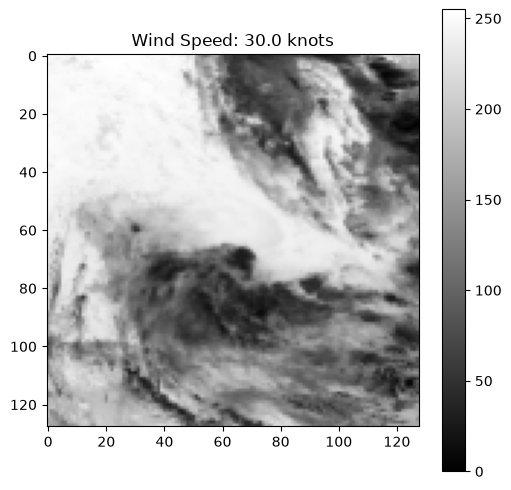

In [3]:
import matplotlib.pyplot as plt

# Load one image and its label
with h5py.File(h5_path, 'r') as f:
    sample_image = f['Images'][0]

print("Image shape:", sample_image.shape)

# Display first channel (e.g., Infrared)
plt.figure(figsize=(6,6))
plt.imshow(sample_image[:,:,0], cmap='gray')
plt.title(f"Wind Speed: {labels[0][5]} knots")
plt.colorbar()
plt.show()

Min wind speed: 10.0
Max wind speed: 168.0
Mean wind speed: 51.006452837350544


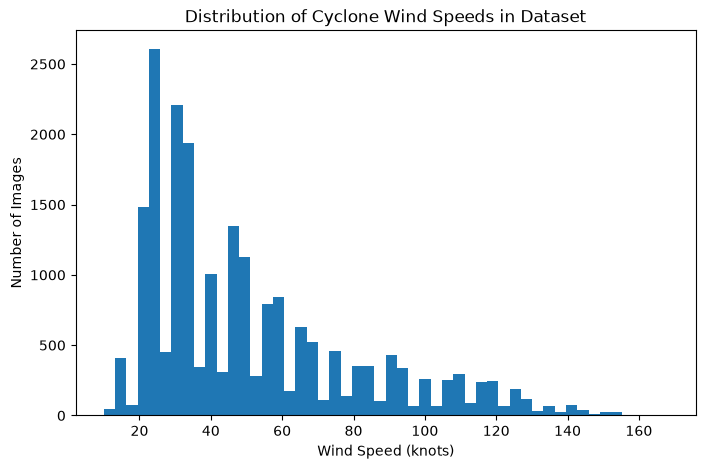

In [4]:
import pandas as pd

# Extract wind speeds from all labels
wind_speeds = labels[:, 5].astype(float)

print("Min wind speed:", wind_speeds.min())
print("Max wind speed:", wind_speeds.max())
print("Mean wind speed:", wind_speeds.mean())

plt.figure(figsize=(8,5))
plt.hist(wind_speeds, bins=50)
plt.xlabel("Wind Speed (knots)")
plt.ylabel("Number of Images")
plt.title("Distribution of Cyclone Wind Speeds in Dataset")
plt.show()

<Axes: >

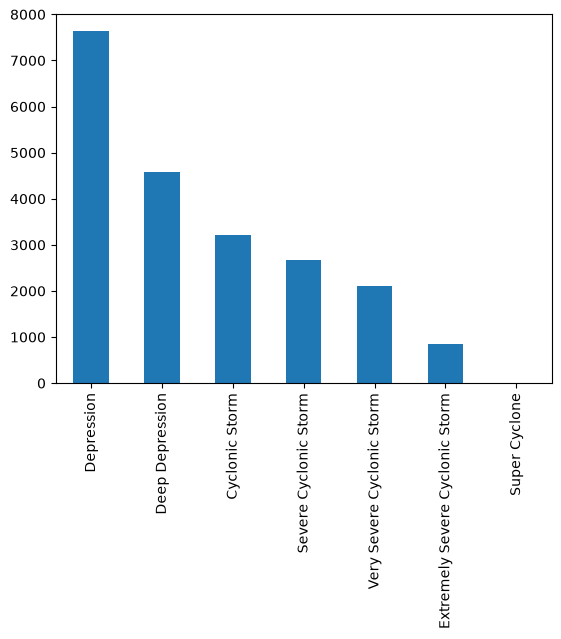

In [5]:
def wind_to_category(speed):
    if speed < 34: return "Depression"
    elif speed < 48: return "Deep Depression"
    elif speed < 64: return "Cyclonic Storm"
    elif speed < 90: return "Severe Cyclonic Storm"
    elif speed < 120: return "Very Severe Cyclonic Storm"
    elif speed < 165: return "Extremely Severe Cyclonic Storm"
    else: return "Super Cyclone"

categories = [wind_to_category(s) for s in wind_speeds]
import pandas as pd
pd.Series(categories).value_counts().plot(kind='bar')

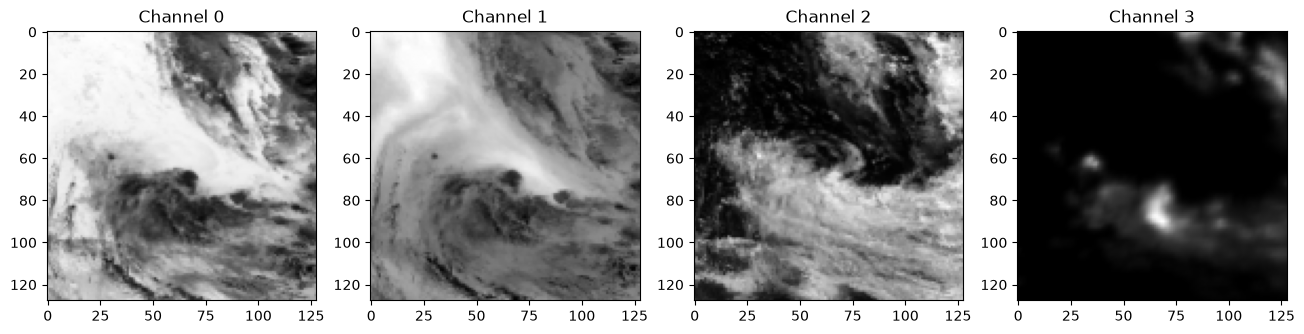

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for i in range(4):
    axes[i].imshow(sample_image[:,:,i], cmap='gray')
    axes[i].set_title(f"Channel {i}")
plt.show()

In [7]:
with h5py.File(h5_path, 'r') as f:
    sample_check = f['Images'][:100]  # load fresh, file open rehte hue
    print("NaN in first 100 images:", np.isnan(sample_check).sum())

print("Unique basins:", set(labels[:,0]))

NaN in first 100 images: 0
Unique basins: {'WPAC', 'EPAC', 'ATLN'}


Depression                         7636
Deep Depression                    4588
Cyclonic Storm                     3220
Severe Cyclonic Storm              2670
Very Severe Cyclonic Storm         2100
Extremely Severe Cyclonic Storm     858
Super Cyclone                         4
Name: count, dtype: int64


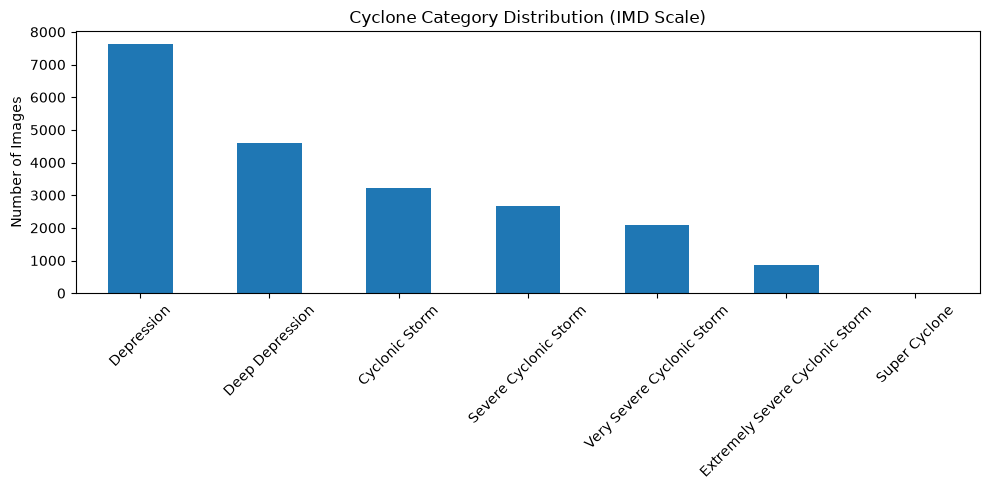

In [8]:
def wind_to_category(speed):
    if speed < 34: return "Depression"
    elif speed < 48: return "Deep Depression"
    elif speed < 64: return "Cyclonic Storm"
    elif speed < 90: return "Severe Cyclonic Storm"
    elif speed < 120: return "Very Severe Cyclonic Storm"
    elif speed < 165: return "Extremely Severe Cyclonic Storm"
    else: return "Super Cyclone"

categories = [wind_to_category(s) for s in wind_speeds]

import pandas as pd
category_counts = pd.Series(categories).value_counts()
print(category_counts)

plt.figure(figsize=(10,5))
category_counts.plot(kind='bar')
plt.title("Cyclone Category Distribution (IMD Scale)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Depression                          7636
Deep Depression                     4588
Cyclonic Storm                      3220
Severe Cyclonic Storm               2670
Very Severe Cyclonic Storm          2100
Extremely Severe / Super Cyclone     862
Name: count, dtype: int64


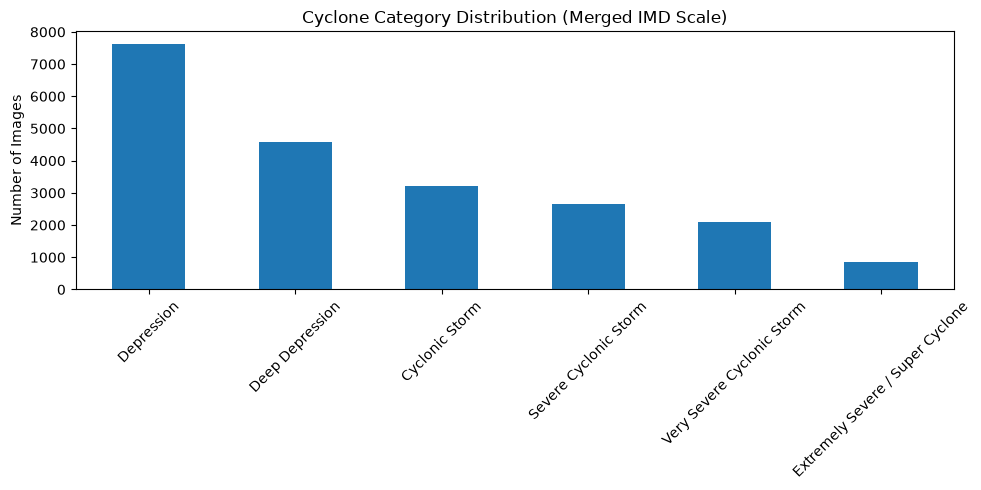

In [9]:
def wind_to_category(speed):
    if speed < 34: return "Depression"
    elif speed < 48: return "Deep Depression"
    elif speed < 64: return "Cyclonic Storm"
    elif speed < 90: return "Severe Cyclonic Storm"
    elif speed < 120: return "Very Severe Cyclonic Storm"
    else: return "Extremely Severe / Super Cyclone"   # 120+ sab isi me merge

categories = [wind_to_category(s) for s in wind_speeds]

category_counts = pd.Series(categories).value_counts()
print(category_counts)

plt.figure(figsize=(10,5))
category_counts.plot(kind='bar')
plt.title("Cyclone Category Distribution (Merged IMD Scale)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import h5py

with h5py.File(h5_path, 'r') as f:
    print("Available keys/datasets in H5 file:")
    for key in f.keys():
        print(f"  - {key}: shape={f[key].shape}, dtype={f[key].dtype}")

Available keys/datasets in H5 file:
  - Images: shape=(21076, 128, 128, 4), dtype=float32


In [11]:
import os
for root, dirs, files in os.walk("../data"):
    for file in files:
        print(os.path.join(root, file))

../data/.DS_Store
../data/metadata.csv
../data/processed/regression_norm_params.json
../data/processed/encoded_labels.npy
../data/processed/class_weights.json
../data/processed/test_idx.npy
../data/processed/train_idx.npy
../data/processed/val_idx.npy
../data/processed/category_mapping.json
../data/raw/insat_3d_ds - Sheet.csv
../data/raw/.DS_Store
../data/raw/thecycloneimagedataset.zip
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/63.jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/77.jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/85(2).jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/62.jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/74.jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/60.jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/48.jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/64(2).jpg
../data/raw/insat3d_ir_cyclone_ds/CYCLONE_DATASET_INFRARED/42(3).jpg
../data/

In [13]:
import os
size = os.path.getsize("../data/metadata.csv")
print("File size (bytes):", size)

with open("../data/metadata.csv", "r") as f:
    content = f.read()
    print("Content length:", len(content))
    print("First 500 chars:", content[:500])

File size (bytes): 0
Content length: 0
First 500 chars: 


In [14]:
insat_meta = pd.read_csv("../data/raw/insat_3d_ds - Sheet.csv")
print("Columns:", insat_meta.columns.tolist())
print("Shape:", insat_meta.shape)
insat_meta.head(10)

Columns: ['img_name', 'label']
Shape: (136, 2)


,img_name,label
0,25.jpg,25
1,27.jpg,27
2,28.jpg,28
3,30.jpg,30
4,30(1).jpg,30
5,31.jpg,31
6,32.jpg,32
7,32(1).jpg,32
8,33.jpg,33
9,33(1).jpg,33
